In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/oil spill data set"

 10555314.zip
 archive.zip
'CSIRO_Sentinel-1_SAR_image_dataset_of_oil-_and_non-oil_features_for_machine_learning_(_Deep_Learning_)-2YRsS0lU-.zip'
 data-10-00117-v2.pdf
 es1348.pdf
'final dataset used for oil spill'
'oil spill.lnk'


In [3]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill"

dataset-final


In [4]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final"

dataset


In [5]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset"

test  train  Validation


In [6]:
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train"
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/test"
!ls "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation"

'Non Oil Spill'  'Oil Spill'
'Non Oil Spill'  'Oil Spill'
'Non Oil Spill'  'Oil Spill'


In [7]:
TRAIN_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train"


In [8]:
TEST_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/test"


In [9]:
VAL_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation"


In [10]:
import os

for split, path in [("Train", TRAIN_DIR), ("Test", TEST_DIR), ("Val", VAL_DIR)]:
    print(split, "exists:", os.path.exists(path))
    print("  Oil Spill images:", len(os.listdir(os.path.join(path, "Oil Spill"))))
    print("  Non Oil Spill images:", len(os.listdir(os.path.join(path, "Non Oil Spill"))))


Train exists: True
  Oil Spill images: 1400
  Non Oil Spill images: 1400
Test exists: True
  Oil Spill images: 300
  Non Oil Spill images: 300
Val exists: True
  Oil Spill images: 300
  Non Oil Spill images: 300


In [11]:
data = []

for split, path in [("train", TRAIN_DIR), ("test", TEST_DIR), ("val", VAL_DIR)]:
    for label in ["Oil Spill", "Non Oil Spill"]:
        count = len(os.listdir(os.path.join(path, label)))
        data.append({
            "split": split,
            "class": label,
            "count": count
        })

import pandas as pd
df = pd.DataFrame(data)
df


,split,class,count
0,train,Oil Spill,1400
1,train,Non Oil Spill,1400
2,test,Oil Spill,300
3,test,Non Oil Spill,300
4,val,Oil Spill,300
5,val,Non Oil Spill,300


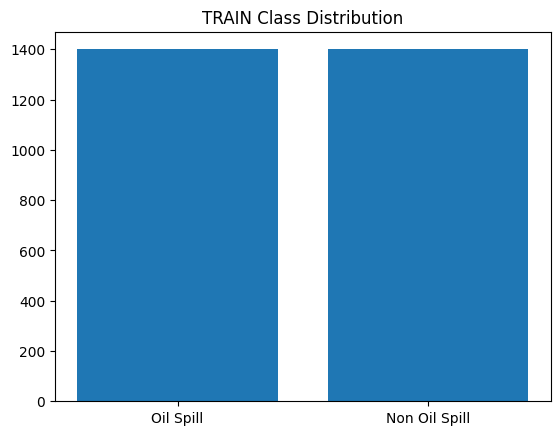

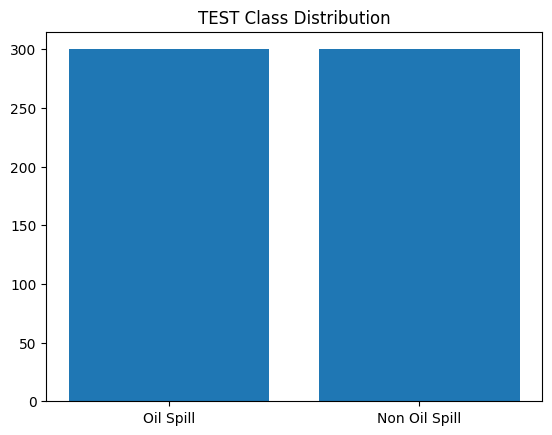

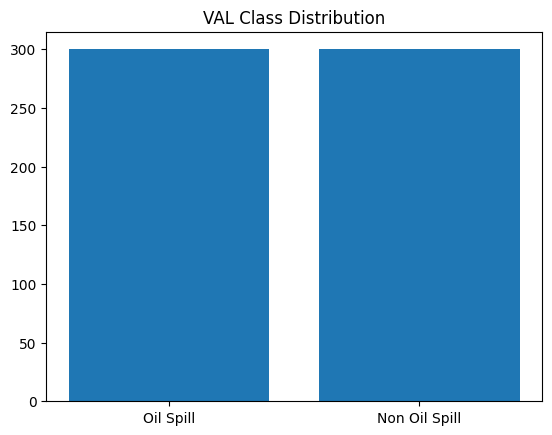

In [12]:
import matplotlib.pyplot as plt

for split in df["split"].unique():
    sub = df[df["split"] == split]
    plt.bar(sub["class"], sub["count"])
    plt.title(f"{split.upper()} Class Distribution")
    plt.show()


In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


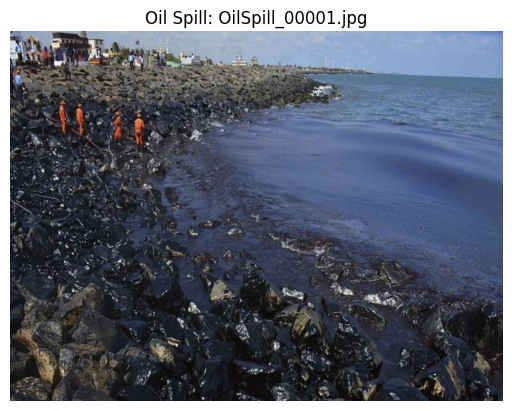

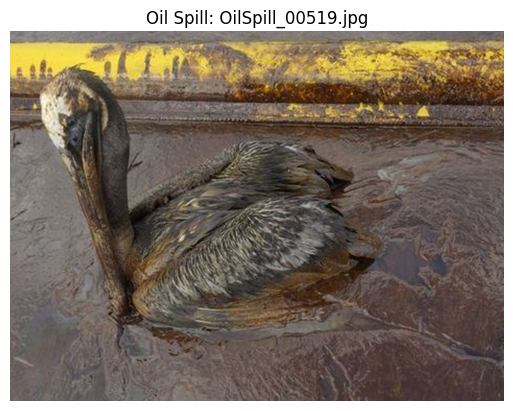

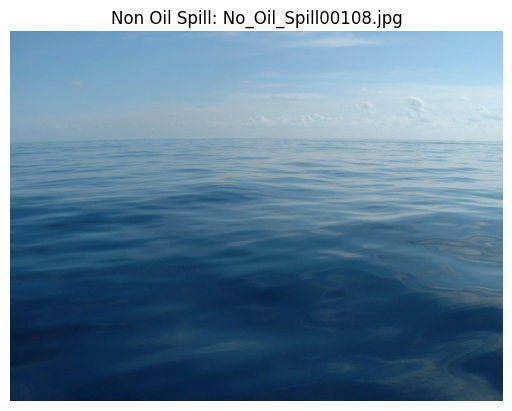

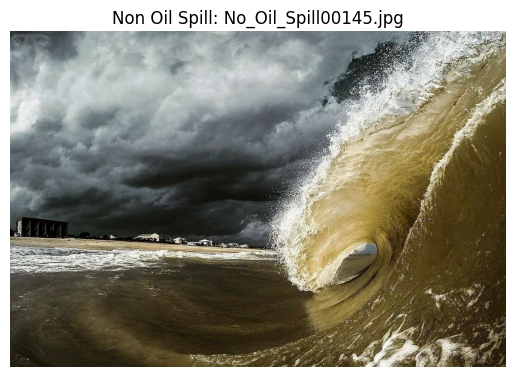

In [14]:
import random

# Pick 2 random images from each class in train
for label in ["Oil Spill", "Non Oil Spill"]:
    files = os.listdir(os.path.join(TRAIN_DIR, label))
    sample_files = random.sample(files, 2)

    for f in sample_files:
        img_path = os.path.join(TRAIN_DIR, label, f)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(f"{label}: {f}")
        plt.axis('off')
        plt.show()


In [15]:
TARGET_SIZE = (256, 256)  # resize all images to 256x256

def preprocess_image(img):
    img = cv2.resize(img, TARGET_SIZE)
    img = img / 255.0  # normalize to 0-1
    return img

def load_images_from_folder(folder):
    images = []
    for f in os.listdir(folder):
        img_path = os.path.join(folder, f)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = preprocess_image(img)
        images.append(img)
    return np.array(images)


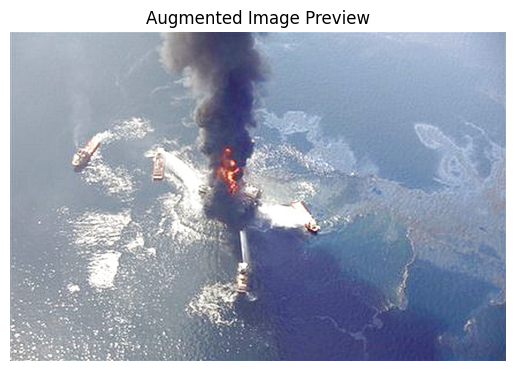

In [16]:
!pip install -q albumentations

import albumentations as A

# Simple augmentation: horizontal flip + brightness
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

# Preview on one image
sample_img_path = os.path.join(TRAIN_DIR, "Oil Spill", os.listdir(os.path.join(TRAIN_DIR, "Oil Spill"))[0])
img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

aug = transform(image=img)
plt.imshow(aug['image'])
plt.title("Augmented Image Preview")
plt.axis('off')
plt.show()


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

class OilSpillDataset(Dataset):
    def __init__(self, root_dir, classes=["Oil Spill", "Non Oil Spill"], transform=None):
        self.samples = []
        for label, class_name in enumerate(classes):
            folder = os.path.join(root_dir, class_name)
            for f in os.listdir(folder):
                self.samples.append((os.path.join(folder, f), label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE)
        img = img / 255.0
        img = np.transpose(img, (2,0,1))  # HWC -> CHW
        if self.transform:
            img = self.transform(image=img)['image']
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Test
train_dataset = OilSpillDataset(TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

for imgs, labels in train_loader:
    print("Batch image shape:", imgs.shape)
    print("Batch labels:", labels)
    break


Batch image shape: torch.Size([4, 3, 256, 256])
Batch labels: tensor([1, 1, 1, 1])


In [18]:
!pip install -q torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt


In [19]:
TARGET_SIZE = (224, 224)  # ResNet usually uses 224x224

class OilSpillDataset(Dataset):
    def __init__(self, root_dir, classes=["Oil Spill","Non Oil Spill"], transform=None):
        self.samples = []
        for label, class_name in enumerate(classes):
            folder = os.path.join(root_dir, class_name)
            for f in os.listdir(folder):
                self.samples.append((os.path.join(folder, f), label))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, TARGET_SIZE)
        if self.transform:
            img = self.transform(image=img)['image']
        img = img / 255.0
        img = np.transpose(img, (2,0,1))  # HWC -> CHW
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)


In [20]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

val_transform = A.Compose([])  # No augmentation for validation/test


In [21]:
BATCH_SIZE = 16

train_dataset = OilSpillDataset(TRAIN_DIR, transform=train_transform)
val_dataset   = OilSpillDataset(VAL_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # 2 classes: Oil Spill, Non Oil Spill
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [24]:
NUM_EPOCHS = 5  # Start with 5 for testing

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * imgs.size(0)
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_acc = correct / total * 100

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Epoch 1/5 | Train Loss: 0.1346 | Val Loss: 0.0219 | Val Acc: 99.50%
Epoch 2/5 | Train Loss: 0.0327 | Val Loss: 0.0266 | Val Acc: 99.33%
Epoch 3/5 | Train Loss: 0.0273 | Val Loss: 0.0503 | Val Acc: 97.67%
Epoch 4/5 | Train Loss: 0.0180 | Val Loss: 0.0058 | Val Acc: 99.83%
Epoch 5/5 | Train Loss: 0.0383 | Val Loss: 0.0148 | Val Acc: 99.50%


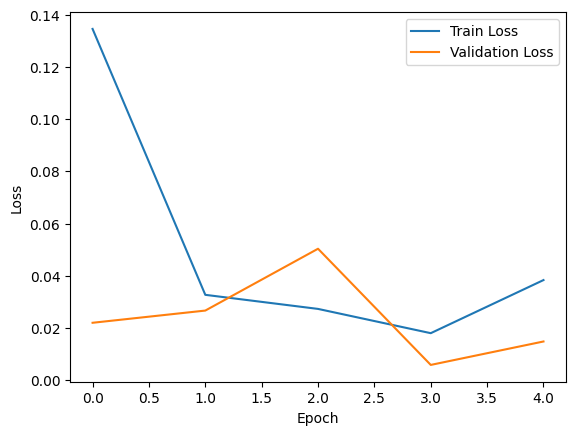

In [25]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [26]:
torch.save(model.state_dict(), "oil_spill_model.pth")


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [30]:
if 'train_dataset' in globals():
    print("'train_dataset' is defined.")
else:
    print("'train_dataset' is NOT defined.")

if 'val_dataset' in globals():
    print("'val_dataset' is defined.")
else:
    print("'val_dataset' is NOT defined.")

'train_dataset' is defined.
'val_dataset' is defined.


In [31]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


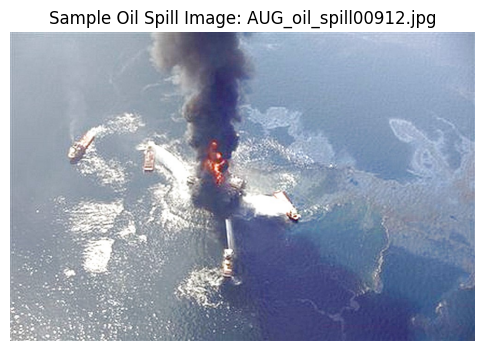

In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Get a path to an actual image from the 'Oil Spill' class in the training directory
# TRAIN_DIR was defined earlier as: /content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train
# We will pick the first image found in the 'Oil Spill' subfolder
oil_spill_train_path = os.path.join(TRAIN_DIR, 'Oil Spill')
sample_image_filename = os.listdir(oil_spill_train_path)[0]
img_path = os.path.join(oil_spill_train_path, sample_image_filename)

# Load the image
img = cv2.imread(img_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {img_path}")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.title(f"Sample Oil Spill Image: {sample_image_filename}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [33]:
def preprocess(img, mask):
    img = cv2.resize(img, (256,256))
    mask = cv2.resize(mask, (256,256))
    img = img / 255.0
    mask = mask / 255.0
    return img, mask


In [34]:
import albumentations as A

augment = A.Compose([
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.RandomRotate90(),
    A.RandomBrightnessContrast()
])


In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models


In [36]:
def UNet():
    inputs = layers.Input((256,256,1))

    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256,3,activation='relu',padding='same')(p2)

    u1 = layers.UpSampling2D()(c3)
    m1 = layers.concatenate([u1,c2])

    u2 = layers.UpSampling2D()(m1)
    m2 = layers.concatenate([u2,c1])

    outputs = layers.Conv2D(1,1,activation='sigmoid')(m2)

    return models.Model(inputs, outputs)


In [37]:
model = UNet()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 256, 256,  │          0 │ concatenate[0][0] │
│ (UpSampling2D)      │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 448)              │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │        449 │ concatenate_1[0]… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 370,113 (1.41 MB)

 Trainable params: 370,113 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

The `tf.data.Dataset` objects for both the training and validation sets have already been created. The following code shows how this was done:

In [38]:
import tensorflow as tf
import os
import cv2
import numpy as np
import random

# Define the keras_data_generator function here to ensure it's in scope
def keras_data_generator(image_paths, labels, batch_size):
    combined = list(zip(image_paths, labels))
    while True:
        random.shuffle(combined)
        batch_images = []
        batch_labels = []
        for img_path, label in combined:
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Could not load image from {img_path}. Skipping.")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (256, 256))
            img = img / 255.0
            img = np.expand_dims(img, axis=-1)
            batch_images.append(img)
            batch_labels.append(label)
            if len(batch_images) == batch_size:
                yield np.array(batch_images), np.array(batch_labels)
                batch_images = []
                batch_labels = []
        if len(batch_images) > 0:
            yield np.array(batch_images), np.array(batch_labels)
            batch_images = []
            batch_labels = []

# 1. Initialize empty lists
train_image_paths = []
train_labels = []
val_image_paths = []
val_labels = []

# Map class names to integer labels
CLASS_LABELS = {"Oil Spill": 0, "Non Oil Spill": 1}

# 2. Iterate through TRAIN_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(TRAIN_DIR, class_name)
    for img_file in os.listdir(class_folder):
        train_image_paths.append(os.path.join(class_folder, img_file))
        train_labels.append(label_id)

# 3. Iterate through VAL_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(VAL_DIR, class_name)
    for img_file in os.listdir(class_folder):
        val_image_paths.append(os.path.join(class_folder, img_file))
        val_labels.append(label_id)

# 4. Define output_types
output_types = (tf.float32, tf.int64)

# 5. Define output_shapes
output_shapes = (tf.TensorShape([None, 256, 256, 1]), tf.TensorShape([None]))

# 6. Create the train_dataset
train_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(train_image_paths, train_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# 7. Create the val_dataset
val_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(val_image_paths, val_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# 8. Print the datasets to verify their creation
print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)

# Example of fetching a batch from the train_dataset to verify content
for images, labels in train_dataset.take(1):
    print("\nFirst batch from train_dataset:")
    print("  Image batch shape:", images.shape)
    print("  Label batch shape:", labels.shape)
    print("  Sample labels:", labels.numpy())
    break

Train Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Validation Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

First batch from train_dataset:
  Image batch shape: (16, 256, 256, 1)
  Label batch shape: (16,)
  Sample labels: [0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1]


# Task
Define a Keras-compatible Python generator function `keras_data_generator` that loads images from specified paths, converts them to grayscale, resizes them to (256, 256), normalizes pixel values to [0, 1], adds a channel dimension to make them (256, 256, 1), and yields the processed image along with its corresponding label.

## Define Keras-compatible Data Generator Function

### Subtask:
Create a Python generator function `keras_data_generator` that will iterate through the dataset paths, load each image, convert it to grayscale, resize it to `(256,256)`, normalize its pixel values to `[0, 1]`, add a channel dimension for Keras compatibility `(256,256,1)`, and yield the processed image and its corresponding label.


**Reasoning**:
I need to define a Python generator function `keras_data_generator` that will preprocess images and yield them in batches, adhering to the specifications provided in the subtask instructions.



In [39]:
import random
import numpy as np
import cv2

def keras_data_generator(image_paths, labels, batch_size):
    # Combine image_paths and labels for shuffling
    combined = list(zip(image_paths, labels))

    while True:
        # Shuffle combined list at the beginning of each epoch
        random.shuffle(combined)

        batch_images = []
        batch_labels = []

        for img_path, label in combined:
            # a. Load the image
            img = cv2.imread(img_path)

            # Check if image is loaded successfully
            if img is None:
                print(f"Warning: Could not load image from {img_path}. Skipping.")
                continue

            # b. Convert to grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # c. Resize to (256, 256)
            img = cv2.resize(img, (256, 256))

            # d. Normalize pixel values
            img = img / 255.0

            # e. Expand dimensions for Keras compatibility (256, 256) -> (256, 256, 1)
            img = np.expand_dims(img, axis=-1)

            # f. Append to batch lists
            batch_images.append(img)
            batch_labels.append(label)

            # g. If batch_size is reached, yield and reset
            if len(batch_images) == batch_size:
                yield np.array(batch_images), np.array(batch_labels)
                batch_images = []
                batch_labels = []

        # If there are remaining samples after the loop, yield them
        if len(batch_images) > 0:
            yield np.array(batch_images), np.array(batch_labels)
            batch_images = []
            batch_labels = []

print("Keras-compatible data generator function 'keras_data_generator' defined.")

Keras-compatible data generator function 'keras_data_generator' defined.


## Create TensorFlow Datasets

### Subtask:
Use `tf.data.Dataset.from_generator` to create `tf.data.Dataset` objects for both the training and validation sets. Configure the `output_types` and `output_shapes` appropriately for images and labels.


**Reasoning**:
The subtask requires creating TensorFlow Datasets using `tf.data.Dataset.from_generator`. This involves preparing image paths and labels for both training and validation sets, defining the output types and shapes, and then instantiating the datasets with the previously defined `keras_data_generator` function.



In [40]:
import tensorflow as tf

# 1. Initialize empty lists
train_image_paths = []
train_labels = []
val_image_paths = []
val_labels = []

# Map class names to integer labels
CLASS_LABELS = {"Oil Spill": 0, "Non Oil Spill": 1}

# 2. Iterate through TRAIN_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(TRAIN_DIR, class_name)
    for img_file in os.listdir(class_folder):
        train_image_paths.append(os.path.join(class_folder, img_file))
        train_labels.append(label_id)

# 3. Iterate through VAL_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(VAL_DIR, class_name)
    for img_file in os.listdir(class_folder):
        val_image_paths.append(os.path.join(class_folder, img_file))
        val_labels.append(label_id)

# 4. Define output_types
output_types = (tf.float32, tf.int64)

# 5. Define output_shapes
output_shapes = (tf.TensorShape([None, 256, 256, 1]), tf.TensorShape([None]))

# 6. Create the train_dataset
train_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(train_image_paths, train_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# 7. Create the val_dataset
val_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(val_image_paths, val_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# 8. Print the datasets to verify their creation
print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)

# Example of fetching a batch from the train_dataset to verify content
for images, labels in train_dataset.take(1):
    print("\nFirst batch from train_dataset:")
    print("  Image batch shape:", images.shape)
    print("  Label batch shape:", labels.shape)
    print("  Sample labels:", labels.numpy())
    break

Train Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Validation Dataset: <_FlatMapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

First batch from train_dataset:
  Image batch shape: (16, 256, 256, 1)
  Label batch shape: (16,)
  Sample labels: [1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1]


## Adapt Model Architecture to Match Data

### Subtask:
Modify the UNet model to perform binary classification, making it compatible with the whole-image class labels provided by the `tf.data.Dataset` objects.


**Reasoning**:
The current `UNet` model is designed for segmentation, not classification. To adapt it for binary classification, I need to modify its architecture by removing the segmentation output layer, adding a global average pooling layer, and a final dense layer with a sigmoid activation for binary classification.



In [41]:
def UNet_Classifier():
    inputs = layers.Input((256,256,1))

    c1 = layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(256,3,activation='relu',padding='same')(p2)

    # Removed UpSampling and concatenation for segmentation
    # Add GlobalAveragePooling2D for classification
    global_pool = layers.GlobalAveragePooling2D()(c3)

    # Add a Dense layer for binary classification output
    outputs = layers.Dense(1, activation='sigmoid')(global_pool)

    return models.Model(inputs, outputs)

print("Modified UNet_Classifier function defined for binary classification.")

Modified UNet_Classifier function defined for binary classification.


**Reasoning**:
Now that the `UNet_Classifier` function is defined, I need to instantiate this new model and compile it with the appropriate optimizer, loss function, and metrics for binary classification, as specified in the instructions.



In [43]:
model = UNet_Classifier()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
print("UNet_Classifier model instantiated and compiled.")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369,921 (1.41 MB)

 Trainable params: 369,921 (1.41 MB)

 Non-trainable params: 0 (0.00 B)

UNet_Classifier model instantiated and compiled.


**Reasoning**:
Before fitting the model, I need to calculate the `steps_per_epoch` for the training set and `validation_steps` for the validation set, as required when using `tf.data.Dataset` with a generator for `model.fit()`. Then, I will train the model.



In [44]:
import math
import tensorflow as tf
import os

# Define directory paths (copied from earlier cells)
TRAIN_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train"
TEST_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/test"
VAL_DIR = "/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation"

# Define BATCH_SIZE (copied from earlier cells)
BATCH_SIZE = 16

# --- Start of code copied from cell 78b4920a to define dependencies ---
# 1. Initialize empty lists
train_image_paths = []
train_labels = []
val_image_paths = []
val_labels = []

# Map class names to integer labels
CLASS_LABELS = {"Oil Spill": 0, "Non Oil Spill": 1}

# 2. Iterate through TRAIN_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(TRAIN_DIR, class_name)
    print(f"Attempting to access training class folder: '{class_folder}'") # Debug print
    if not os.path.exists(class_folder):
        print(f"Error: Training class directory DOES NOT EXIST: '{class_folder}'. Please ensure the path is correct and your Google Drive is mounted and accessible.")
        raise FileNotFoundError(f"Training class directory not found: '{class_folder}'. Please ensure the path is correct and your Google Drive is mounted and accessible.")
    for img_file in os.listdir(class_folder):
        train_image_paths.append(os.path.join(class_folder, img_file))
        train_labels.append(label_id)

# 3. Iterate through VAL_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(VAL_DIR, class_name)
    print(f"Attempting to access validation class folder: '{class_folder}'") # Debug print
    if not os.path.exists(class_folder):
        print(f"Error: Validation class directory DOES NOT EXIST: '{class_folder}'. Please ensure the path is correct and your Google Drive is mounted and accessible.")
        raise FileNotFoundError(f"Validation class directory not found: '{class_folder}'. Please ensure the path is correct and your Google Drive is mounted and accessible.")
    for img_file in os.listdir(class_folder):
        val_image_paths.append(os.path.join(class_folder, img_file))
        val_labels.append(label_id)

# 4. Define output_types
output_types = (tf.float32, tf.int64)

# 5. Define output_shapes
output_shapes = (tf.TensorShape([None, 256, 256, 1]), tf.TensorShape([None]))

# 6. Create the train_dataset
train_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(train_image_paths, train_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# 7. Create the val_dataset
val_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(val_image_paths, val_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# --- End of incorporated code from cell 78b4920a ---

# --- Start of model definition and compilation (copied from cell ee53038d) ---
def UNet_Classifier():
    inputs = tf.keras.layers.Input((256,256,1))

    c1 = tf.keras.layers.Conv2D(64,3,activation='relu',padding='same')(inputs)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(128,3,activation='relu',padding='same')(p1)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    c3 = tf.keras.layers.Conv2D(256,3,activation='relu',padding='same')(p2)

    # Removed UpSampling and concatenation for segmentation
    # Add GlobalAveragePooling2D for classification
    global_pool = tf.keras.layers.GlobalAveragePooling2D()(c3)

    # Add a Dense layer for binary classification output
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(global_pool)

    return tf.keras.models.Model(inputs, outputs)

model = UNet_Classifier()
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("UNet_Classifier model instantiated and compiled.")
# --- End of model definition and compilation ---


# Calculate steps per epoch for training and validation
steps_per_epoch = math.ceil(len(train_image_paths) / BATCH_SIZE)
validation_steps = math.ceil(len(val_image_paths) / BATCH_SIZE)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")

# Fit the model
history = model.fit(
    train_dataset,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=validation_steps,
    epochs=20
)

print("Model training complete.")

Attempting to access training class folder: '/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train/Oil Spill'
Attempting to access training class folder: '/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/train/Non Oil Spill'
Attempting to access validation class folder: '/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation/Oil Spill'
Attempting to access validation class folder: '/content/drive/MyDrive/oil spill data set/final dataset used for oil spill/dataset-final/dataset/Validation/Non Oil Spill'
UNet_Classifier model instantiated and compiled.
Steps per epoch: 175
Validation steps: 38
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1105s 6s/step - accuracy: 0.5085 - loss: 0.6947 - val_accuracy: 0.5533 - val_loss: 0.6920
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1162s 7s/step - accuracy: 0.5365 - loss: 0.6904 - val_accuracy: 0.5300 - val_loss

# Task
Evaluate the performance of the trained classification model for oil spill detection.

## Review model training history

### Subtask:
Analyze the training and validation loss and accuracy curves to understand the model's learning process and identify potential overfitting or underfitting.


**Reasoning**:
I need to extract the training and validation loss and accuracy from the `history` object and then plot them to visualize the model's performance over epochs.



In [1]:
import matplotlib.pyplot as plt

# 1. Extract training and validation metrics from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

# 2. Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 3. Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 4. Display both plots
plt.show()

NameError: name 'history' is not defined

## Evaluate model on test dataset

### Subtask:
Evaluate the trained classification model on the held-out test dataset to obtain final performance metrics such as loss and accuracy.


**Reasoning**:
I need to prepare the test dataset by gathering image paths and their corresponding labels from the `TEST_DIR`. This is a prerequisite for creating the `tf.data.Dataset` for evaluation.



In [ ]:
import math

# 1. Initialize empty lists for test_image_paths and test_labels
test_image_paths = []
test_labels = []

# Map class names to integer labels (already defined, but good to ensure context)
# CLASS_LABELS = {"Oil Spill": 0, "Non Oil Spill": 1}
# Assuming CLASS_LABELS and TEST_DIR are already defined from previous cells

# 2. Iterate through TEST_DIR to populate lists
for class_name, label_id in CLASS_LABELS.items():
    class_folder = os.path.join(TEST_DIR, class_name)
    for img_file in os.listdir(class_folder):
        test_image_paths.append(os.path.join(class_folder, img_file))
        test_labels.append(label_id)

# 3. Create a tf.data.Dataset object named test_dataset using tf.data.Dataset.from_generator
# 4. Pass a lambda function that calls keras_data_generator with test_image_paths, test_labels, and BATCH_SIZE
# 5. Specify output_types and output_shapes as previously defined
test_dataset = tf.data.Dataset.from_generator(
    lambda: keras_data_generator(test_image_paths, test_labels, BATCH_SIZE),
    output_types=output_types,
    output_shapes=output_shapes
)

# 6. Calculate the test_steps
test_steps = math.ceil(len(test_image_paths) / BATCH_SIZE)

print(f"Test Dataset: {test_dataset}")
print(f"Number of test images: {len(test_image_paths)}")
print(f"Test steps: {test_steps}")

# Verify a batch from the test_dataset
for images, labels in test_dataset.take(1):
    print("\nFirst batch from test_dataset:")
    print("  Image batch shape:", images.shape)
    print("  Label batch shape:", labels.shape)
    print("  Sample labels:", labels.numpy())
    break

In [ ]:
model.evaluate(test_dataset)


In [ ]:
pred = model.predict(img[np.newaxis,...])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Input"); plt.imshow(img, cmap='gray')
plt.subplot(1,3,2); plt.title("Ground Truth"); plt.imshow(mask, cmap='gray')
plt.subplot(1,3,3); plt.title("Prediction"); plt.imshow(pred[0], cmap='gray')
plt.show()


In [ ]:
pip install streamlit


In [ ]:
import streamlit as st
import cv2
import numpy as np

st.title("Oil Spill Detection System")

file = st.file_uploader("Upload Satellite Image")

if file:
    img = cv2.imread(file.name,0)
    img = cv2.resize(img,(256,256))/255.0
    pred = model.predict(img[np.newaxis,...])
    st.image(pred[0], caption="Detected Oil Spill")


**Reasoning**:
Now that the test dataset and `test_steps` are prepared, I will evaluate the trained model on this dataset to obtain the final loss and accuracy.



In [ ]:
test_results = model.evaluate(test_dataset, steps=test_steps)
print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")